In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/sahilhussain2410/cig-project-aiml-26/cig_ps/train-labels.csv
/kaggle/input/datasets/sahilhussain2410/cig-project-aiml-26/cig_ps/train_images/train-10782.png
/kaggle/input/datasets/sahilhussain2410/cig-project-aiml-26/cig_ps/train_images/train-14434.png
/kaggle/input/datasets/sahilhussain2410/cig-project-aiml-26/cig_ps/train_images/train-13737.png
/kaggle/input/datasets/sahilhussain2410/cig-project-aiml-26/cig_ps/train_images/train-10621.png
/kaggle/input/datasets/sahilhussain2410/cig-project-aiml-26/cig_ps/train_images/train-15431.png
/kaggle/input/datasets/sahilhussain2410/cig-project-aiml-26/cig_ps/train_images/train-16884.png
/kaggle/input/datasets/sahilhussain2410/cig-project-aiml-26/cig_ps/train_images/train-19022.png
/kaggle/input/datasets/sahilhussain2410/cig-project-aiml-26/cig_ps/train_images/train-4023.png
/kaggle/input/datasets/sahilhussain2410/cig-project-aiml-26/cig_ps/train_images/train-167.png
/kaggle/input/datasets/sahilhussain2410/cig-project-aim

# Preprocessing

In [3]:
import os
import cv2

from PIL import Image

import torch
from torch.utils.data import Dataset

from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
train_label=pd.read_csv('/kaggle/input/datasets/sahilhussain2410/cig-project-aiml-26/cig_ps/train-labels.csv',index_col=0)
df=train_label.copy()

In [5]:
TRAIN_IMG_DIR='/kaggle/input/datasets/sahilhussain2410/cig-project-aiml-26/cig_ps/train_images'
TEST_IMG_DIR='/kaggle/input/datasets/sahilhussain2410/cig-project-aiml-26/cig_ps/test_images'

In [6]:
# 5396E9 interpreted as 5396*(10^9) , due to E as exponent, so correcting it
df.loc[2184,'text']='5396E9'

In [7]:
# its interpreted as date, so correcting it
df.loc[6819,'text']= '4MAR54'

In [8]:
# A-Z + 0-9, all possible characters in images

CHARS = "ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789"

char_to_idx = {
    char: idx for idx, char in enumerate(CHARS)
}

idx_to_char = {
    idx: char for idx, char in enumerate(CHARS)
}

NUM_CLASSES = len(CHARS) + 1  # +1 for CTC blank
CTC_BLANK = len(CHARS)
print(NUM_CLASSES)

37


In [9]:
# encode label
def encode_label(text):
    """
    XQ8NE2 -> [23,16,34,13,4,28]
    """

    return [char_to_idx[ch] for ch in text]

In [10]:
# decode indices back to char
def decode_indices(indices):
    return "".join(
        idx_to_char[i]
        for i in indices
        if i in idx_to_char
    )

In [11]:
# Apply CLAHE (Contrast Limited Adaptive Histogram Equalization) to an image
def apply_clahe(image):
    """
    image:
        grayscale uint8 image
    """

    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8, 8)
    )

    image = clahe.apply(image)

    return image

In [12]:
# full preprocessing function
def preprocess_image(image):
    """
    image:
        grayscale numpy array
    """

    image = apply_clahe(image)

    return image

## The OCR Dataset Class

In [13]:
#The class turns rows from a dataframe into model-ready OCR samples by loading and preprocessing images and encoding text labels when training.
class OCRDataset(Dataset):

    def __init__(
        self,
        dataframe,
        image_dir,
        transform=None,
        train=True
    ):

        self.df = dataframe.reset_index(drop=True)

        self.image_dir = image_dir

        self.transform = transform

        self.train = train

    def __len__(self):

        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        image_name = row["image"]

        image_path = os.path.join(
            self.image_dir,
            image_name
        )

        image = cv2.imread(
            image_path,
            cv2.IMREAD_GRAYSCALE
        )

        image = preprocess_image(image)

        if self.transform is not None:

            image = self.transform(image=image)["image"]

        else:

            image = image.astype(np.float32) / 255.0

            image = torch.tensor(
                image,
                dtype=torch.float32
            ).unsqueeze(0)

        if self.train:

            label = row["text"]

            label_encoded = encode_label(label)

            return {
                "image": image,
                "label": torch.tensor(
                    label_encoded,
                    dtype=torch.long
                ),
                "label_length": len(label_encoded),
                "text": label
            }

        return {
            "image": image,
            "image_name": image_name
        }

In [14]:
#converts a list of OCR samples into a batch by stacking images, concatenating variable-length label sequences, and recording each label's length so the batch can be used with CTC loss.

def ctc_collate_fn(batch):

    images = torch.stack(
        [item["image"] for item in batch]
    )

    labels = [
        item["label"]
        for item in batch
    ]

    label_lengths = torch.tensor(
        [item["label_length"] for item in batch],
        dtype=torch.long
    )

    targets = torch.cat(labels)

    texts = [
        item["text"]
        for item in batch
    ]

    return {
        "images": images,
        "targets": targets,
        "target_lengths": label_lengths,
        "texts": texts
    }

In [15]:
# Train/ valid split
train_df, valid_df = train_test_split(
    df,
    test_size=0.1,
    random_state=42,
    shuffle=True
)

print(len(train_df))
print(len(valid_df))

18000
2000


In [16]:
# checking whether its correct or not
train_dataset = OCRDataset(
    dataframe=train_df,
    image_dir=TRAIN_IMG_DIR,
    transform=None,
    train=True
)

sample = train_dataset[0]

print(sample["image"].shape)
print(sample["text"])
print(sample["label"])

torch.Size([1, 100, 200])
XBR3M3
tensor([23,  1, 17, 29, 12, 29])


# Augmentations + DataLoader + Visualization

In [17]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

##  Augmentation


In [18]:
train_transform = A.Compose([

    # CLAHE enhancement
    A.CLAHE(
        clip_limit=2.0,
        tile_grid_size=(8, 8),
        p=0.2
    ),

    # Rotation + Translation + Scaling
    A.ShiftScaleRotate(
        shift_limit=0.10,
        scale_limit=0.10,
        rotate_limit=10,
        border_mode=cv2.BORDER_CONSTANT,
        p=0.30
    ),

    # Gaussian Noise
    A.GaussNoise(
        std_range=(0.02, 0.08),
        p=0.50
    ),

    # Motion Blur
    A.MotionBlur(
        blur_limit=3,
        p=0.20
    ),

    # Gaussian Blur
    A.GaussianBlur(
        blur_limit=(3, 5),
        p=0.20
    ),

    # Random Erasing / Occlusion
    A.CoarseDropout(
        num_holes_range=(1, 3),
        hole_height_range=(10, 20),
        hole_width_range=(10, 20),
        fill=0,
        p=0.30
    ),

    # Brightness & Contrast
    A.RandomBrightnessContrast(
        brightness_limit=0.20,
        contrast_limit=0.20,
        p=0.30
    ),

    # Normalize
    A.Normalize(
        mean=(0.5,),
        std=(0.5,)
    ),

    ToTensorV2()

])

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [19]:
# Tranformation for validation images, only normalization
valid_transform = A.Compose([

    A.Normalize(
        mean=(0.5,),
        std=(0.5,)
    ),

    ToTensorV2()

])

In [20]:
# creating the dataset for train and val
train_dataset = OCRDataset(
    dataframe=train_df,
    image_dir=TRAIN_IMG_DIR,
    transform=train_transform,
    train=True
)

valid_dataset = OCRDataset(
    dataframe=valid_df,
    image_dir=TRAIN_IMG_DIR,
    transform=valid_transform,
    train=True
)

## Data Loader creation

In [21]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
    collate_fn=ctc_collate_fn
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
    collate_fn=ctc_collate_fn
)

In [22]:
# checking data loaders
batch = next(iter(train_loader))

print(batch["images"].shape)
print(batch["targets"].shape)
print(batch["target_lengths"].shape)

print(batch["texts"][:5])

torch.Size([64, 1, 100, 200])
torch.Size([384])
torch.Size([64])
['X9UQGK', '983MNS', 'BSHPVS', '8Z5AUD', 'AWRR8V']


## Visualizing images (augmentation)

In [23]:
def visualize_augmentations(dataset, idx=0, n=6):

    sample = dataset.df.iloc[idx]

    image_path = os.path.join(
        dataset.image_dir,
        sample["image"]
    )

    image = cv2.imread(
        image_path,
        cv2.IMREAD_GRAYSCALE
    )

    image = preprocess_image(image)

    fig, axes = plt.subplots(
        1,
        n,
        figsize=(18, 4)
    )

    for i in range(n):

        aug = train_transform(image=image)

        img = aug["image"]

        img = img.squeeze().cpu().numpy()

        img = img * 0.5 + 0.5

        axes[i].imshow(
            img,
            cmap="gray"
        )

        axes[i].axis("off")

    plt.show()

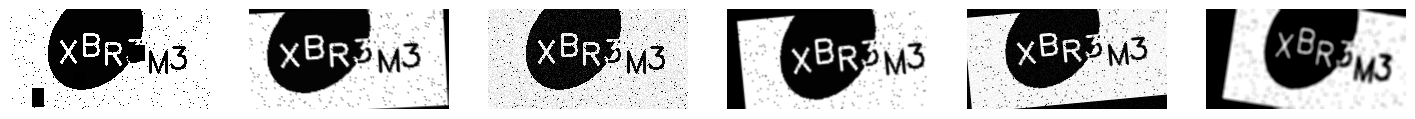

In [24]:
visualize_augmentations(
    train_dataset,
    idx=0,
    n=6
)

In [25]:
# function to see train_img original from directory
def show_train_image(idx, train_img_dir):
    
    img_path = os.path.join(
        train_img_dir,
        f"train-{idx}.png"
    )

    img = cv2.imread(
        img_path,
        cv2.IMREAD_GRAYSCALE
    )

    if img is None:
        print(f"Image not found: {img_path}")
        return

    plt.figure(figsize=(6, 3))
    plt.imshow(img, cmap="gray")
    plt.title(f"train-{idx}.png")
    plt.axis("off")
    plt.show()

In [26]:
#show_train_image(20,TRAIN_IMG_DIR)

# Model Architecture

In [27]:
import torch
import torch.nn as nn

In [28]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print(device)

cuda


### This CNN extracts visual features from noisy CAPTCHA images

In [29]:
class CNNBackbone(nn.Module):

    def __init__(self):

        super().__init__()

        self.features = nn.Sequential(

            # 100 x 200

            nn.Conv2d(
                1,
                64,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(2, 2),

            # 50 x 100

            nn.Conv2d(
                64,
                128,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(2, 2),

            # 25 x 50

            nn.Conv2d(
                128,
                256,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(
                kernel_size=(2, 1),
                stride=(2, 1)
            ),

            # 12 x 50

            nn.Conv2d(
                256,
                512,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(
                kernel_size=(2, 1),
                stride=(2, 1)
            ),

            # 6 x 50

            nn.Conv2d(
                512,
                512,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),

            nn.AdaptiveAvgPool2d(
                (1, None)
            )

            # 1 x 50

        )

    def forward(self, x):

        return self.features(x)

In [30]:
cnn = CNNBackbone()

x = torch.randn(
    4,
    1,
    100,
    200
)

y = cnn(x)

print(y.shape)

torch.Size([4, 512, 1, 50])


### The BiLSTM learns relationships between neighboring characters.

In [31]:
class SequenceModel(nn.Module):

    def __init__(self):

        super().__init__()

        self.lstm = nn.LSTM(
            input_size=512,
            hidden_size=256,
            num_layers=2,
            dropout=0.3,
            bidirectional=True,
            batch_first=True
        )

    def forward(self, x):

        x, _ = self.lstm(x)

        return x

In [32]:
class CTCHead(nn.Module):

    def __init__(self, num_classes):

        super().__init__()

        self.fc = nn.Linear(
            512,
            num_classes
        )

    def forward(self, x):

        x = self.fc(x)

        return x

In [33]:
class CRNN(nn.Module):

    def __init__(self, num_classes):

        super().__init__()

        self.cnn = CNNBackbone()

        self.sequence_model = SequenceModel()

        self.classifier = CTCHead(
            num_classes
        )

    def forward(self, x):

        # ---------------------
        # CNN
        # ---------------------

        x = self.cnn(x)

        # [B,512,1,50]

        x = x.squeeze(2)

        # [B,512,50]

        x = x.permute(
            0,
            2,
            1
        )

        # [B,50,512]

        # ---------------------
        # BiLSTM
        # ---------------------

        x = self.sequence_model(x)

        # [B,50,512]

        # ---------------------
        # Classifier
        # ---------------------

        x = self.classifier(x)

        # [B,50,37]

        return x

In [34]:
model = CRNN(
    num_classes=NUM_CLASSES
)

dummy = torch.randn(
    4,
    1,
    100,
    200
)

out = model(dummy)

print(out.shape)

torch.Size([4, 50, 37])


In [35]:
# total parameter count of model
total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(
    f"Total Params: {total_params:,}"
)

print(
    f"Trainable Params: {trainable_params:,}"
)

Total Params: 7,085,477
Trainable Params: 7,085,477


In [36]:
model = model.to(device)

## CTC Loss

In [37]:
import torch.nn as nn

ctc_loss = nn.CTCLoss(
    blank=CTC_BLANK,
    reduction="mean",
    zero_infinity=True
)

## Greedy Decoder

In [38]:
# logits back to text
def greedy_decode(logits):

    preds = logits.argmax(dim=2)

    decoded_texts = []

    for pred in preds:

        decoded = []

        previous = -1

        for p in pred.cpu().numpy():

            if p == CTC_BLANK:

                previous = p
                continue

            if p == previous:

                continue

            decoded.append(idx_to_char[p])

            previous = p

        decoded_texts.append(
            "".join(decoded)
        )

    return decoded_texts

### cheking decoder

In [39]:
# with torch.no_grad():

#     preds = greedy_decode(
#         logits
#     )

# print(preds[:5])
# print(batch["texts"][:5])
# here it would be random prediction, bcz modle is not trained

## CER Metric

In [40]:
!pip install -q python-Levenshtein

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 3.9 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 44.3 MB/s eta 0:00:0000:0100:01


In [41]:
from Levenshtein import distance

In [42]:
# CER Function
def calculate_cer(preds, targets):

    total_distance = 0
    total_chars = 0

    for pred, target in zip(
        preds,
        targets
    ):

        total_distance += distance(
            pred,
            target
        )

        total_chars += len(target)

    cer = total_distance / total_chars

    return cer

In [43]:
# batch = next(iter(valid_loader))

# images = batch["images"].to(device)

# with torch.no_grad():

#     logits = model(images)

# preds = greedy_decode(logits)
# print(preds)
# cer = calculate_cer(
#     preds,
#     batch["texts"]
# )

# print(cer)

# Training

In [44]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=1e-4
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)


In [45]:
from torch.cuda.amp import GradScaler

scaler = GradScaler()

/tmp/ipykernel_58/2885796805.py:3: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


In [46]:
from tqdm.auto import tqdm
from torch.cuda.amp import autocast

In [47]:
def train_one_epoch(
    model,
    loader,
    optimizer,
    ctc_loss,
    scaler,
    device
):

    model.train()

    running_loss = 0

    progress_bar = tqdm(
        loader,
        total=len(loader)
    )

    for batch in progress_bar:

        images = batch["images"].to(device)

        targets = batch["targets"].to(device)

        target_lengths = (
            batch["target_lengths"]
            .to(device)
        )

        optimizer.zero_grad()

        with autocast():

            logits = model(images)

            # [B,T,C]
            logits = logits.permute(
                1,
                0,
                2
            )

            log_probs = logits.log_softmax(
                dim=2
            )

            batch_size = images.size(0)

            input_lengths = torch.full(
                (batch_size,),
                log_probs.size(0),
                dtype=torch.long,
                device=device
            )

            loss = ctc_loss(
                log_probs,
                targets,
                input_lengths,
                target_lengths
            )

        scaler.scale(loss).backward()

        # research recommendation
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=5.0
        )

        scaler.step(optimizer)

        scaler.update()

        running_loss += loss.item()

        progress_bar.set_postfix(
            loss=f"{loss.item():.4f}"
        )

    epoch_loss = (
        running_loss /
        len(loader)
    )

    return epoch_loss

In [48]:
@torch.no_grad()
def validate_one_epoch(
    model,
    loader,
    ctc_loss,
    device
):

    model.eval()

    running_loss = 0

    all_preds = []
    all_targets = []

    progress_bar = tqdm(
        loader,
        total=len(loader)
    )

    for batch in progress_bar:

        images = batch["images"].to(device)

        targets = batch["targets"].to(device)

        target_lengths = (
            batch["target_lengths"]
            .to(device)
        )

        logits = model(images)

        preds = greedy_decode(logits)

        all_preds.extend(preds)
        all_targets.extend(batch["texts"])

        logits_ctc = logits.permute(
            1,
            0,
            2
        )

        log_probs = logits_ctc.log_softmax(
            dim=2
        )

        batch_size = images.size(0)

        input_lengths = torch.full(
            (batch_size,),
            log_probs.size(0),
            dtype=torch.long,
            device=device
        )

        loss = ctc_loss(
            log_probs,
            targets,
            input_lengths,
            target_lengths
        )

        running_loss += loss.item()

    val_loss = (
        running_loss /
        len(loader)
    )

    cer = calculate_cer(
        all_preds,
        all_targets
    )

    return val_loss, cer

In [49]:
# checkpoint
import os

CHECKPOINT_DIR = "checkpoints"

os.makedirs(
    CHECKPOINT_DIR,
    exist_ok=True
)

## Training loop

In [50]:
def train_model(
    model,
    train_loader,
    valid_loader,
    optimizer,
    scheduler,
    ctc_loss,
    scaler,
    device,
    epochs=15
):

    best_cer = float("inf")

    history = {
        "train_loss": [],
        "val_loss": [],
        "val_cer": []
    }

    for epoch in range(epochs):

        print("\n" + "="*60)
        print(
            f"Epoch {epoch+1}/{epochs}"
        )
        print("="*60)

        # ------------------
        # TRAIN
        # ------------------

        train_loss = train_one_epoch(
            model,
            train_loader,
            optimizer,
            ctc_loss,
            scaler,
            device
        )

        # ------------------
        # VALIDATE
        # ------------------

        val_loss, val_cer = validate_one_epoch(
            model,
            valid_loader,
            ctc_loss,
            device
        )

        # ------------------
        # SCHEDULER
        # ------------------

        scheduler.step(val_cer)

        # ------------------
        # STORE HISTORY
        # ------------------

        history["train_loss"].append(
            train_loss
        )

        history["val_loss"].append(
            val_loss
        )

        history["val_cer"].append(
            val_cer
        )

        current_lr = (
            optimizer
            .param_groups[0]["lr"]
        )

        print(
            f"Train Loss : {train_loss:.4f}"
        )

        print(
            f"Val Loss   : {val_loss:.4f}"
        )

        print(
            f"Val CER    : {val_cer:.4f}"
        )

        print(
            f"LR         : {current_lr:.6f}"
        )

        if val_cer < best_cer:

            best_cer = val_cer

            torch.save(
                {
                    "epoch": epoch,
                    "model_state_dict":
                        model.state_dict(),
                    "optimizer_state_dict":
                        optimizer.state_dict(),
                    "best_cer":
                        best_cer
                },
                os.path.join(
                    CHECKPOINT_DIR,
                    "best_model.pth"
                )
            )

            print(
                f"✓ New Best CER: "
                f"{best_cer:.4f}"
            )

    return history

In [51]:
history = train_model(
    model,
    train_loader,
    valid_loader,
    optimizer,
    scheduler,
    ctc_loss,
    scaler,
    device,
    epochs=50
)


Epoch 1/50


  0%|          | 0/282 [00:00<?, ?it/s]

/tmp/ipykernel_58/3374555467.py:32: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


  0%|          | 0/32 [00:00<?, ?it/s]

Train Loss : 4.3168
Val Loss   : 3.5765
Val CER    : 0.9560
LR         : 0.000300
✓ New Best CER: 0.9560

Epoch 2/50


...

  0%|          | 0/32 [00:00<?, ?it/s]

Train Loss : 0.0145
Val Loss   : 0.0020
Val CER    : 0.0004
LR         : 0.000005

Epoch 50/50


  0%|          | 0/282 [00:00<?, ?it/s]

  0%|          | 0/32 [00:00<?, ?it/s]

Train Loss : 0.0144
Val Loss   : 0.0021
Val CER    : 0.0004
LR         : 0.000005


## Visualizing Loss Curve

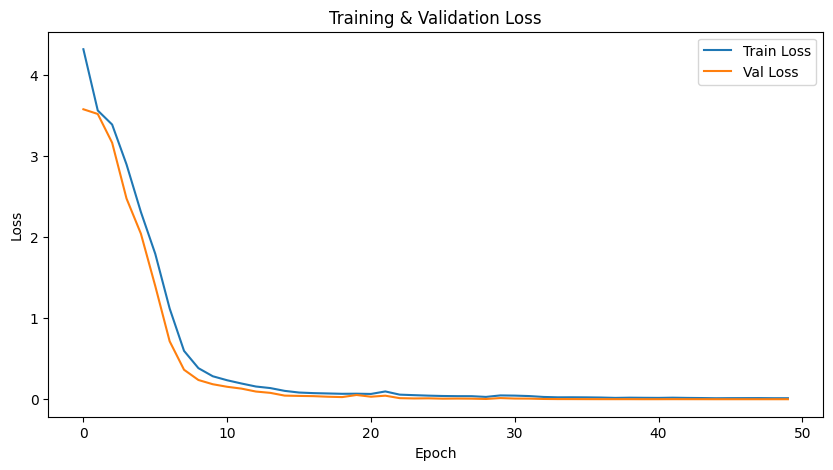

In [52]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))

plt.plot(
    history["train_loss"],
    label="Train Loss"
)

plt.plot(
    history["val_loss"],
    label="Val Loss"
)

plt.legend()

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title(
    "Training & Validation Loss"
)

plt.show()

In [53]:
print(history['val_loss'][-1])
history['train_loss'][-1]


0.0020537692898869864


0.01438718167251696

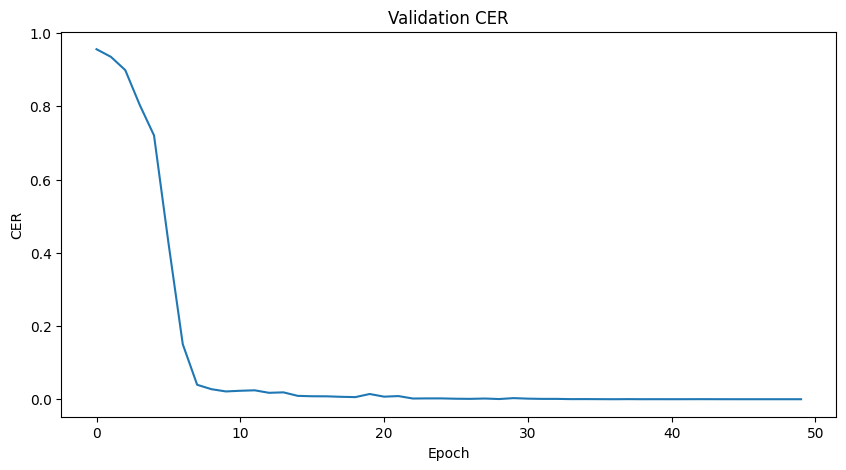

In [54]:
# visulaize CER Curve
plt.figure(figsize=(10,5))

plt.plot(
    history["val_cer"]
)

plt.xlabel("Epoch")

plt.ylabel("CER")

plt.title(
    "Validation CER"
)

plt.show()

In [55]:
# printing the last CER value
history['val_cer'][-1]

0.0004166666666666667

## See Prediction

In [56]:
batch = next(iter(valid_loader))

images = batch["images"].to(device)

with torch.no_grad():

    logits = model(images)

preds = greedy_decode(logits)

for i in range(51,62):

    print(
        f"GT   : {batch['texts'][i]}"
    )

    print(
        f"PRED : {preds[i]}"
    )

    print("-"*40)

GT   : QAH945
PRED : QAH945
----------------------------------------
GT   : 67SAEA
PRED : 67SAEA
----------------------------------------
GT   : CXK6KX
PRED : CXK6KX
----------------------------------------
GT   : ZCF5KX
PRED : ZCF5KX
----------------------------------------
GT   : P86468
PRED : P86468
----------------------------------------
GT   : 79WCHT
PRED : 79WCHT
----------------------------------------
GT   : EWAKK9
PRED : EWAKK9
----------------------------------------
GT   : 5M4W7S
PRED : 5M4W7S
----------------------------------------
GT   : 22YBDW
PRED : 22YBDW
----------------------------------------
GT   : HSAGBH
PRED : HSAGBH
----------------------------------------
GT   : 3UMSKT
PRED : 3UMSKT
----------------------------------------


In [57]:
def sequence_accuracy(preds, targets):

    correct = 0

    for p, t in zip(preds, targets):

        if p == t:
            correct += 1

    return correct / len(targets)

In [58]:
# get the accuracy of model
all_preds = []
all_targets = []

model.eval()

with torch.no_grad():

    for batch in valid_loader:

        images = batch["images"].to(device)

        logits = model(images)

        preds = greedy_decode(logits)

        all_preds.extend(preds)
        all_targets.extend(batch["texts"])

acc = sequence_accuracy(
    all_preds,
    all_targets
)

print(acc)

0.9975


In [59]:
wrong = []

for gt, pred in zip(all_targets, all_preds):

    if gt != pred:
        wrong.append((gt, pred))

print("Total Errors:", len(wrong))

for i in range(min(30, len(wrong))):

    print(wrong[i])

Total Errors: 5
('VVHXDD', 'VHVHXDD')
('777RQK', '7777RQK')
('KV5777', 'KV57777')
('XF9777', 'XF97777')
('45C777', '45C7777')


# Test Predictions

In [60]:
checkpoint = torch.load(
    "checkpoints/best_model.pth",
    map_location=device
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model = model.to(device)

model.eval()

print(
    "Best CER:",
    checkpoint["best_cer"]
)

print(
    "Best Epoch:",
    checkpoint["epoch"] + 1
)

Best CER: 0.0004166666666666667
Best Epoch: 37


## Test Dataset 

In [61]:
class TestDataset(Dataset):

    def __init__(
        self,
        image_dir,
        transform=None
    ):

        self.image_dir = image_dir

        self.transform = transform

        self.image_names = sorted(
            os.listdir(image_dir),
            key=lambda x: int(
                x.split("-")[1].split(".")[0]
            )
        )

    def __len__(self):

        return len(self.image_names)

    def __getitem__(self, idx):

        image_name = self.image_names[idx]

        image_path = os.path.join(
            self.image_dir,
            image_name
        )

        image = cv2.imread(
            image_path,
            cv2.IMREAD_GRAYSCALE
        )

        image = preprocess_image(image)

        image = self.transform(
            image=image
        )["image"]

        return {
            "image": image,
            "image_name": image_name
        }

In [63]:
TEST_IMAGE_DIR = "/kaggle/input/datasets/sahilhussain2410/cig-project-aiml-26/cig_ps/test_images"

test_dataset = TestDataset(
    image_dir=TEST_IMAGE_DIR,
    transform=valid_transform
)

In [64]:
test_loader = DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

## Test Predictions

In [65]:
@torch.no_grad()
def predict_test_set(
    model,
    loader,
    device
):

    model.eval()

    image_names = []

    predictions = []

    for batch in tqdm(loader):

        images = batch["image"].to(device)

        logits = model(images)

        preds = greedy_decode(logits)

        image_names.extend(
            batch["image_name"]
        )

        predictions.extend(preds)

    return image_names, predictions

In [66]:
image_names, predictions = predict_test_set(
    model,
    test_loader,
    device
)

print(len(image_names))
print(len(predictions))

  0%|          | 0/40 [00:00<?, ?it/s]

5000
5000


In [67]:
for i in range(15):

    print(
        image_names[i],
        " -> ",
        predictions[i]
    )

test-0.png  ->  QVTQ8A
test-1.png  ->  7PSW9D
test-2.png  ->  WJ2WNY
test-3.png  ->  RFHJD4
test-4.png  ->  K7ZUF2
test-5.png  ->  CPMUBK
test-6.png  ->  UZDRAW
test-7.png  ->  2YDPJR
test-8.png  ->  H5SG63
test-9.png  ->  B2Z823
test-10.png  ->  7DUP98
test-11.png  ->  6CUKRD
test-12.png  ->  DX3YJ3
test-13.png  ->  YWU8AG
test-14.png  ->  WYKX9E


## Submission CSV

In [68]:
submission = pd.DataFrame({

    "image": image_names,

    "prediction": predictions

})

submission.head()

,image,prediction
0,test-0.png,QVTQ8A
1,test-1.png,7PSW9D
2,test-2.png,WJ2WNY
3,test-3.png,RFHJD4
4,test-4.png,K7ZUF2


In [69]:
submission.to_csv(
    "submission.csv",
    index=False
)

print(
    submission.shape
)

(5000, 2)


In [70]:
print(
    submission.sample(20)
)

              image prediction
1439  test-1439.png     N6EJSD
1994  test-1994.png     BN3B6X
798    test-798.png     R5S5FG
2769  test-2769.png     PGAGDF
1615  test-1615.png     H5J9MB
749    test-749.png     PSUVVN
3434  test-3434.png     KJYDFX
4186  test-4186.png     UQMJ9D
3121  test-3121.png     ZMJTVM
2445  test-2445.png     T2CCE3
4677  test-4677.png     4PQT59
761    test-761.png     MU47EA
2525  test-2525.png     X73W6W
1845  test-1845.png     8543A8
1541  test-1541.png     3ENJKV
3976  test-3976.png     8ECPNX
2599  test-2599.png     38AR42
560    test-560.png     VWMV53
3575  test-3575.png     572MVA
4147  test-4147.png     ZD9QWU
